In [ ]:
# preprocessing
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Rescaling

DATASET_PATH = "C:/Users/AHMAD ADAM HAKIMI/Downloads/Machine_Learning_Project/PlantVillage"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split = 0.7,
    subset = 'training',
    seed = 42,
    image_size = (224, 224),
    batch_size = 32
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split = 0.15,
    subset = 'validation',
    seed = 42,
    image_size = (224, 224),
    batch_size = 32
)
class_names = train_dataset.class_names

for images, labels in train_dataset.take(1):    # show sample
    print(f'Features shape: {images.shape}')
    print(f'Target shape: {labels.shape}')

# modelling
def create_model():
    model = tf.keras.models.Sequential([
        Rescaling(1./255, input_shape=(224, 224, 3)),

        # first windowed layer
        Conv2D(32, (3, 3), name = 'first_layer'),
        LeakyReLU(alpha = 0.01),
        MaxPooling2D((2, 2)),
        Dropout(0.1),

        # second windowed layer
        Conv2D(64, (3, 3), name = 'second_layer'),
        LeakyReLU(alpha = 0.01),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # average pooling before dense layer
        GlobalAveragePooling2D(),
        Dense(256, name = 'dense_layer'),
        LeakyReLU(alpha = 0.01),
        Dropout(0.4),

        # output layer
        Dense(len(class_names), activation = 'softmax', name = 'output_layer')
    ])

    model.compile(
        loss = 'sparse_categorical_crossentropy', 
        optimizer = 'Adam', 
        metrics = ['accuracy']
    )

    return model

model = create_model()
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_accuracy',
    mode = 'max',
    patience = 5,
    restore_best_weights = True
)
model.summary()

# train model 
print('Training model...')
history = model.fit(
    train_dataset,
    epochs = 50,
    verbose = True,
    validation_data = val_dataset,
    callbacks = [early_stopping]
)
print('Training done!\n')



Found 16011 files belonging to 10 classes.
Using 4804 files for training.
Found 16011 files belonging to 10 classes.
Using 2401 files for validation.
Features shape: (32, 224, 224, 3)
Target shape: (32,)


c:\Users\AHMAD ADAM HAKIMI\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\AHMAD ADAM HAKIMI\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ first_layer (Conv2D)            │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ second_layer (Conv2D)           │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 109, 109, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,602 (150.79 KB)

 Trainable params: 38,602 (150.79 KB)

 Non-trainable params: 0 (0.00 B)

Training model...
Epoch 1/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 42s 270ms/step - accuracy: 0.2338 - loss: 2.0768 - val_accuracy: 0.3290 - val_loss: 1.8911
Epoch 2/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 43s 284ms/step - accuracy: 0.3616 - loss: 1.8045 - val_accuracy: 0.4461 - val_loss: 1.6250
Epoch 3/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 42s 281ms/step - accuracy: 0.4465 - loss: 1.5748 - val_accuracy: 0.4990 - val_loss: 1.4640
Epoch 4/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 42s 281ms/step - accuracy: 0.4929 - loss: 1.4504 - val_accuracy: 0.5631 - val_loss: 1.2673
Epoch 5/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 43s 282ms/step - accuracy: 0.5477 - loss: 1.3043 - val_accuracy: 0.5681 - val_loss: 1.2110
Epoch 6/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 42s 277ms/step - accuracy: 0.5708 - loss: 1.2349 - val_accuracy: 0.5931 - val_loss: 1.1534
Epoch 7/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 44s 290ms/step - accuracy: 0.5993 - loss: 1.1316 - val_accuracy: 0.6047 - val_loss: 1.1536
Epoch 8/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 44s 292ms/step - accuracy

In [2]:
# evaluate model's metrics
history_dict = list(history.history.items())
with open('runs/classify/tomato_cnn/training_log.txt', 'w') as file:     # save in a file
    file.write(f"Stopped at epoch: {len(history.history['loss'])}\n")
    file.write('\n--- Training Scores ---\n')
    for metrics_name, score in history_dict:
        if not metrics_name.startswith('val_'):
            file.write(f'{metrics_name}: {score[-1]:.4f}\n')
    file.write('\n--- Evaluation Scores ---\n')
    for metrics_name, score in history_dict:
        if metrics_name.startswith('val_'):
            file.write(f'{metrics_name}: {score[-1]:.4f}\n')
with open('runs/classify/tomato_cnn/training_log.txt', 'r') as file:     # print to terminal
    print(file.read())

# save model
# model.export('runs/classify/tomato_cnn')

Stopped at epoch: 46

--- Training Scores ---
accuracy: 0.8566
loss: 0.4208

--- Evaluation Scores ---
val_accuracy: 0.8222
val_loss: 0.5041



In [3]:
# model save
model.save('runs/classify/tomato_cnn/tomato_cnn.keras')

Found 16011 files belonging to 10 classes.
Using 2401 files for validation.
Classification Report
                                      precision    recall  f1-score   support

                      Bacterial spot       0.87      0.87      0.87       327
                        Early blight       0.60      0.61      0.61       147
                         Late blight       0.79      0.70      0.74       286
                           Leaf Mold       0.77      0.57      0.65       150
                  Septoria leaf spot       0.69      0.81      0.74       275
Spider mites Two spotted spider mite       0.73      0.75      0.74       241
                         Target Spot       0.76      0.70      0.73       199
              YellowLeaf  Curl Virus       0.91      0.91      0.91       498
                        mosaic virus       0.78      0.87      0.82        53
                             healthy       0.90      0.99      0.94       225

                            accuracy      

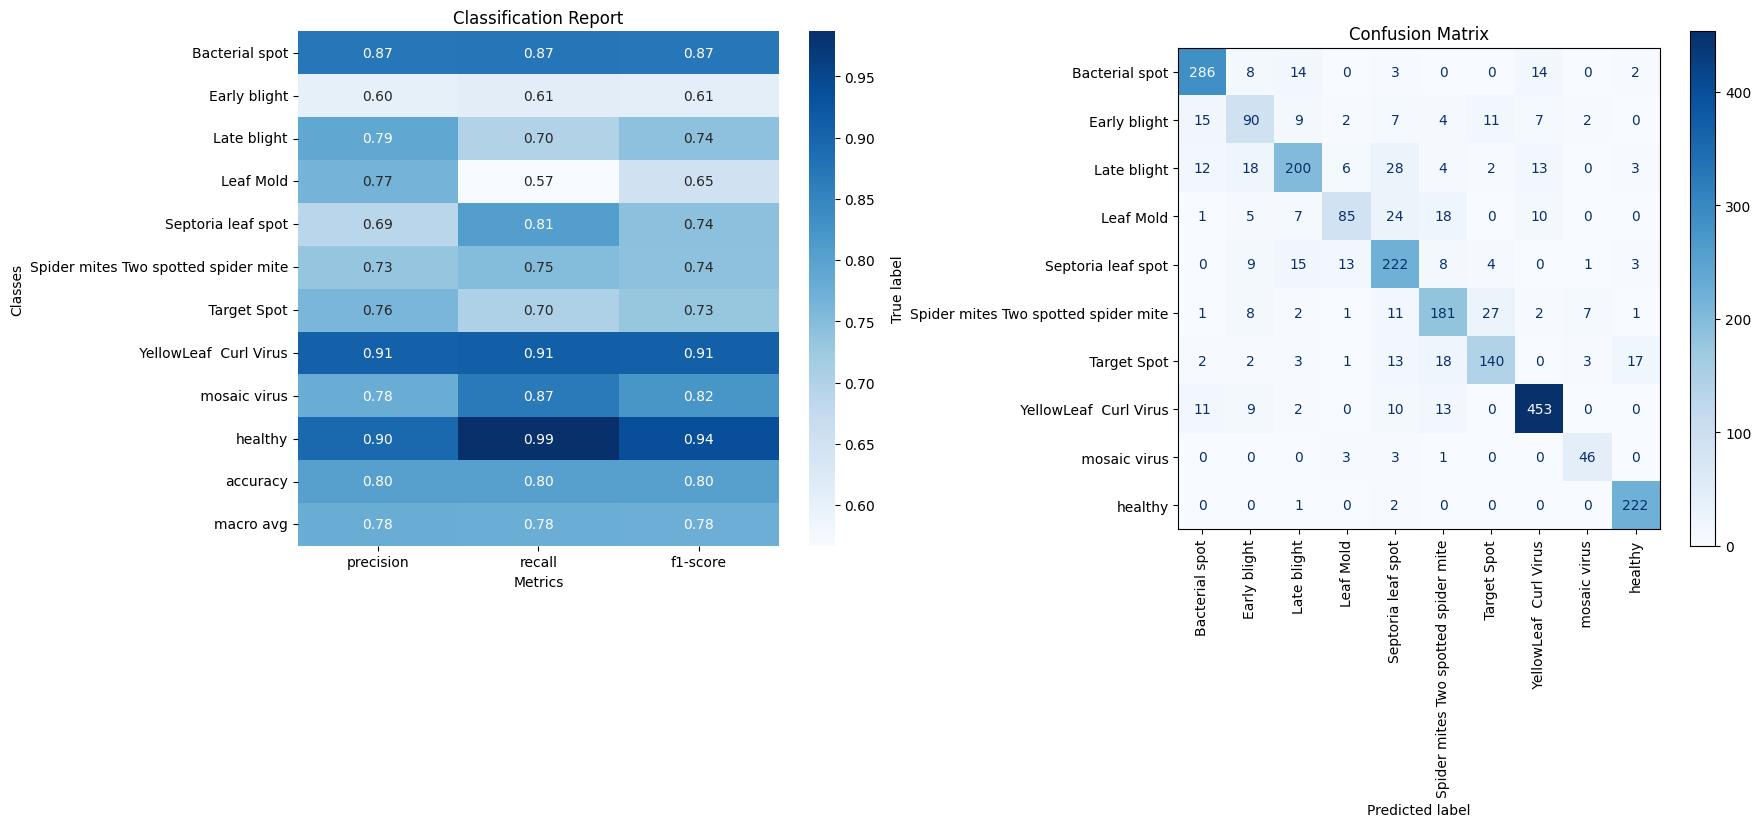

In [7]:
# --------------- PART 3: Model Evaluation ---------------
import tensorflow as tf
import numpy as np

# get some test samples
DATASET_PATH = "C:/Users/AHMAD ADAM HAKIMI/Downloads/Machine_Learning_Project/PlantVillage"
test_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split = 0.15,
    subset = 'validation',
    seed = 42,
    image_size = (224, 224),
    batch_size = 32,
)
class_names = test_dataset.class_names
model = tf.saved_model.load('runs/classify/tomato_cnn')

# create prediction module
def predict(images):
    images = np.array(images, dtype = np.float32)
    preds = model.serve(images).numpy()
    return np.argmax(preds, axis = 1)

# get multiple predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = predict(images)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)


# ----- Evaluate the model predictions by Plotting -----
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize = (18, 8))
short_names = [name.replace('Tomato_', '').replace('Tomato__', '').replace('_', ' ') for name in class_names]

# classification report
print(f'Classification Report\n{classification_report(y_true, y_pred, target_names = short_names)}\n')

report = classification_report(
    y_true, y_pred,
    target_names = short_names,
    output_dict = True
)
report_df = pd.DataFrame(report).transpose()
heatmap_data = report_df.iloc[:-1, :-1]

sns.heatmap(
    heatmap_data,
    annot = True,
    cmap = 'Blues',
    fmt = '.2f',
    ax = axes[0]
)
axes[0].set_title('Classification Report')
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Classes')

# confusion matrix
cm = confusion_matrix(y_true, y_pred)
print(f'Confusion Matrix\n{cm}\n')

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = short_names
)
disp.plot(
    cmap = 'Blues',
    ax = axes[1],
    xticks_rotation = 90,
)
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig('runs/classify/tomato_cnn/model_evaluation.png', dpi = 150, bbox_inches = 'tight')
plt.show()